In [4]:
import pandas as pd
import numpy as np

In [7]:
demographic = pd.read_csv('demographic.csv')
diet = pd.read_csv('diet.csv')
examination = pd.read_csv('examination.csv')
labs = pd.read_csv('labs.csv')
medications = pd.read_csv('medications.csv', encoding='latin1')
questionnaire = pd.read_csv('questionnaire.csv')

In [8]:
print(demographic.columns)
print(diet.columns)
print(examination.columns)
print(labs.columns)
print(medications.columns)
print(questionnaire.columns)

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY',
       'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ',
       'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGE',
       'DMDHRBR4', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'WTINT2YR', 'WTMEC2YR',
       'SDMVPSU', 'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR'],
      dtype='object')
Index(['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT',
       'DR1DBIH', 'DR1DAY', 'DR1LANG',
       ...
       'DRD370QQ', 'DRD370R', 'DRD370RQ', 'DRD370S', 'DRD370SQ', 'DRD370T',
       'DRD370TQ', 'DRD370U', 'DRD370UQ', 'DRD370V'],
      dtype='object', length=168)
Index(['SEQN', 'PEASCST1', 'PEASCTM1', 'PEASCCT1', 'BPXCHR', 'BPAARM',
   

In [9]:
df = demographic.merge(diet, on='SEQN', how='inner') \
                .merge(examination, on='SEQN', how='inner') \
                .merge(labs, on='SEQN', how='inner') \
                .merge(medications, on='SEQN', how='inner') \
                .merge(questionnaire, on='SEQN', how='inner')

print("Final shape:", df.shape)

Final shape: (19580, 1824)


In [10]:
# Drop columns with too many missing values
df = df.dropna(thresh=len(df)*0.5, axis=1)

# Fill remaining missing values
df = df.fillna(df.median(numeric_only=True))

In [11]:
important_features = [
    'SEQN',
    'RIAGENDR',      # Gender
    'RIDAGEYR',      # Age
    'BMXBMI',        # BMI
    'LBXGLU',        # Glucose
    'LBXGH',         # HbA1c
    'BPXSY1',        # Blood pressure
    'BPXDI1',
    'DIQ010'         # Diabetes label (target)
]

# Keep only existing columns
important_features = [col for col in important_features if col in df.columns]

df = df[important_features]

print(df.head())

    SEQN  RIAGENDR  RIDAGEYR  BMXBMI  LBXGH  BPXSY1  BPXDI1  DIQ010
0  73557         1        69    26.7   13.9   122.0    72.0     1.0
1  73557         1        69    26.7   13.9   122.0    72.0     1.0
2  73558         1        54    28.6    9.1   156.0    62.0     1.0
3  73558         1        54    28.6    9.1   156.0    62.0     1.0
4  73558         1        54    28.6    9.1   156.0    62.0     1.0


In [12]:
df.rename(columns={'DIQ010': 'Diabetes'}, inplace=True)

In [13]:
df['Diabetes'] = df['Diabetes'].replace({1:1, 2:0})
df = df.dropna(subset=['Diabetes'])

In [14]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19580 entries, 0 to 19579
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      19580 non-null  int64  
 1   RIAGENDR  19580 non-null  int64  
 2   RIDAGEYR  19580 non-null  int64  
 3   BMXBMI    19580 non-null  float64
 4   LBXGH     19580 non-null  float64
 5   BPXSY1    19580 non-null  float64
 6   BPXDI1    19580 non-null  float64
 7   Diabetes  19580 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 1.2 MB
None
               SEQN      RIAGENDR      RIDAGEYR        BMXBMI         LBXGH  \
count  19580.000000  19580.000000  19580.000000  19580.000000  19580.000000   
mean   78544.159704      1.534627     45.443565     28.365873      5.910608   
std     2935.456571      0.498812     25.559836      8.338658      1.121498   
min    73557.000000      1.000000      0.000000     12.100000      3.500000   
25%    75978.000000      1.000000     20.000000     

In [15]:
df.to_csv('final_diabetes_dataset.csv', index=False)

First 5 rows:
    SEQN  RIAGENDR  RIDAGEYR  BMXBMI  LBXGH  BPXSY1  BPXDI1  Diabetes
0  73557         1        69    26.7   13.9   122.0    72.0       1.0
1  73557         1        69    26.7   13.9   122.0    72.0       1.0
2  73558         1        54    28.6    9.1   156.0    62.0       1.0
3  73558         1        54    28.6    9.1   156.0    62.0       1.0
4  73558         1        54    28.6    9.1   156.0    62.0       1.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19580 entries, 0 to 19579
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      19580 non-null  int64  
 1   RIAGENDR  19580 non-null  int64  
 2   RIDAGEYR  19580 non-null  int64  
 3   BMXBMI    19580 non-null  float64
 4   LBXGH     19580 non-null  float64
 5   BPXSY1    19580 non-null  float64
 6   BPXDI1    19580 non-null  float64
 7   Diabetes  19580 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 1.2 MB
Non

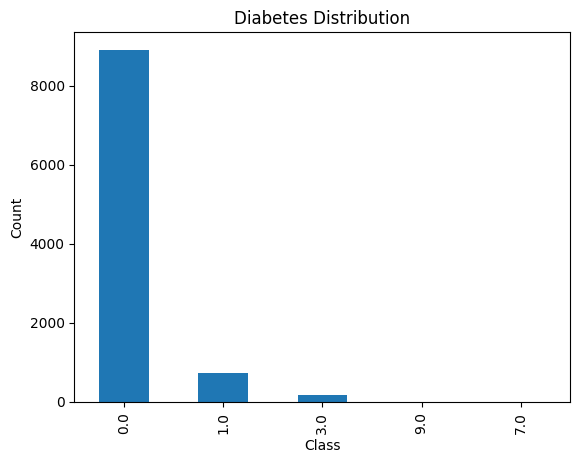

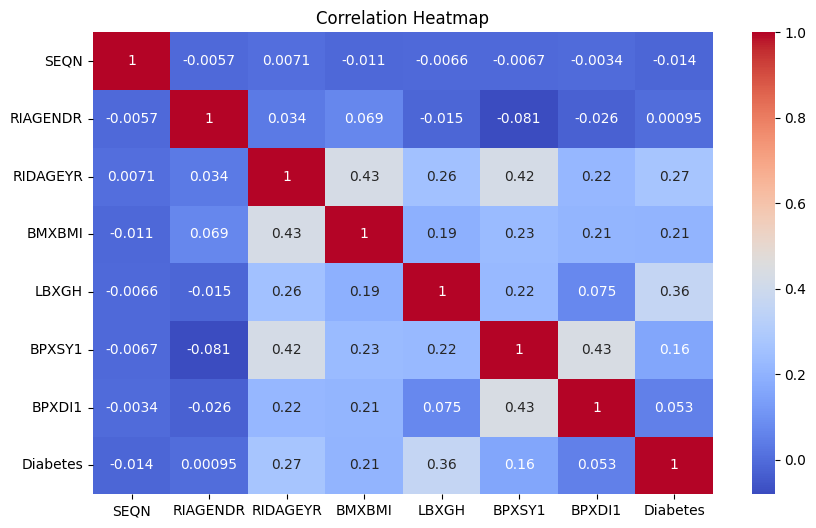

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9192 - loss: 0.2842 - val_accuracy: 0.9098 - val_loss: 0.2107
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9280 - loss: 0.2270 - val_accuracy: 0.9251 - val_loss: 0.2048
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9322 - loss: 0.2182 - val_accuracy: 0.9317 - val_loss: 0.2068
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9340 - loss: 0.2196 - val_accuracy: 0.9307 - val_loss: 0.2089
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9338 - loss: 0.2102 - val_accuracy: 0.9302 - val_loss: 0.2086
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9348 - loss: 0.2113 - val_accuracy: 0.9266 - val_loss: 0.2091
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9326 - loss: 0.2007 - val_accuracy: 0.9353 - val_loss: 0.2108
Epoch 8/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9354 - loss: 0.2091 - val_accuracy: 0.9312 - val_

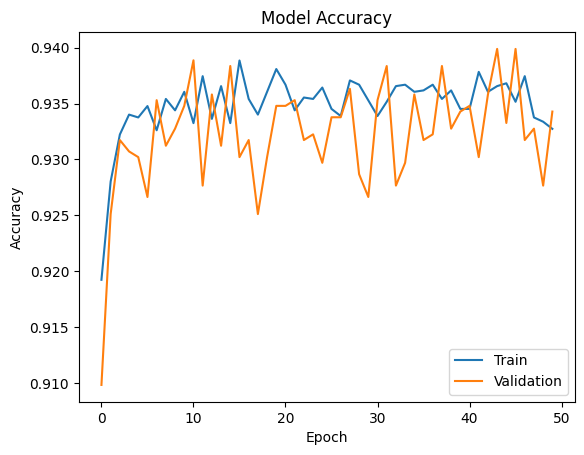

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Confusion Matrix:
[[1748   41    0]
 [  50   86    0]
 [  27   11    0]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      1789
         1.0       0.62      0.63      0.63       136
         3.0       0.00      0.00      0.00        38

    accuracy                           0.93      1963
   macro avg       0.53      0.54      0.53      1963
weighted avg       0.92      0.93      0.93      1963


✅ Model saved successfully!


In [16]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv('final_diabetes_dataset.csv')

print("First 5 rows:")
print(df.head())

# ==============================
# 3. BASIC EDA
# ==============================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ==============================
# 4. DATA CLEANING
# ==============================
# Fill missing values
df = df.fillna(df.median(numeric_only=True))

# Remove duplicates
df = df.drop_duplicates()

# ==============================
# 5. TARGET DISTRIBUTION
# ==============================
plt.figure()
df['Diabetes'].value_counts().plot(kind='bar')
plt.title("Diabetes Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ==============================
# 6. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 7. SPLIT FEATURES & TARGET
# ==============================
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# ==============================
# 8. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. FEATURE SCALING
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 10. BUILD DEEP LEARNING MODEL
# ==============================
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

# ==============================
# 11. COMPILE MODEL
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 12. TRAIN MODEL (EPOCHS)
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=50,              # change to 100 for better results
    batch_size=32,
    validation_data=(X_test, y_test)
)

# ==============================
# 13. EVALUATE MODEL
# ==============================
loss, accuracy = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", accuracy)

# ==============================
# 14. PLOT ACCURACY GRAPH
# ==============================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# ==============================
# 15. PREDICTIONS
# ==============================
pred = model.predict(X_test)
pred = (pred > 0.5).astype(int)

# ==============================
# 16. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, pred)
print("\nConfusion Matrix:")
print(cm)

# ==============================
# 17. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:")
print(classification_report(y_test, pred))

# ==============================
# 18. SAVE MODEL (OPTIONAL)
# ==============================
model.save("diabetes_model.h5")

print("\n✅ Model saved successfully!")

In [17]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('final_diabetes_dataset.csv')

# ==============================
# CLEAN DATA
# ==============================
df = df.fillna(df.median(numeric_only=True))
df = df.drop_duplicates()

# ==============================
# FEATURES & TARGET
# ==============================
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# SCALE
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MODEL
# ==============================
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==============================
# TRAIN
# ==============================
model.fit(X_train, y_train, epochs=50, batch_size=32)

# ==============================
# SAVE MODEL + SCALER
# ==============================
model.save("diabetes_model.h5")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model & scaler saved")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9121 - loss: 0.2832
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9288 - loss: 0.2289
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9327 - loss: 0.2224
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9321 - loss: 0.2127
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9345 - loss: 0.2197
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9348 - loss: 0.2094
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9329 - loss: 0.2117
Epoch 8/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9368 - loss: 0.1993
Epoch 9/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9361 - loss: 0.2094
Epoch 10/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9336 - loss: 0.2071
Epoch 11/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9339 - loss: 0.2086
Epoch 12/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

✅ Model & scaler saved


In [18]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv('final_diabetes_dataset.csv')

# ==============================
# CLEAN DATA
# ==============================
df = df.fillna(df.median(numeric_only=True))
df = df.drop_duplicates()

# ==============================
# FEATURES & TARGET
# ==============================
X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# SCALE
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# MODEL (RANDOM FOREST)
# ==============================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# SAVE MODEL + SCALER
# ==============================
joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model saved successfully!")


✅ Model saved successfully!
